<center> <img src="https://miro.medium.com/v2/resize:fit:1200/1*lbDXL0IuitCRz4mpZ7MmfQ.png" width=55% > </center>

<br><br>

<center> 
    <font size="6">Final Lab (Part 2): Image Classification using Convolutional Neural Networks </font>
</center>
<center> 
    <font size="4">Computer Vision 1 University of Amsterdam</font> 
</center>
<center> 
    <font size="4">Due 23:59PM, October 18, 2024 (Amsterdam time)</font> 
</center>
<center> 
    <font size="4"><b>TA's:  Yue, Konrad & Thies</b></font>
</center>

<br><br>

***

<br><br>

<center>

Student1 ID: 13209701 \
Student1 Name: Thomas Brouwer

Student2 ID: 15127206 \
Student2 Name: Piotr Sobecki

Student3 ID: 15713725 \
Student3 Name: Pedro Pombeiro Curvo

</center>

### **Coding Guidelines**

Your code must be handed in this Jupyter notebook, renamed to **StudentID1_StudentID2_StudentID3.ipynb** before the deadline by submitting it to the Canvas Final Lab: Image Classification Assignment. Please also fill out your names and IDs above.

For full credit, make sure your notebook follows these guidelines:

- Please express your thoughts **concisely**. The number of words does not necessarily correlate with how well you understand the concepts.
- Understand the problem as much as you can. When answering a question, provide evidence (qualitative and/or quantitative results, references to papers, figures, etc.) to support your arguments. Not everything might be explicitly asked for, so think about what might strengthen your arguments to make the notebook self-contained and complete.
- Tables and figures must be accompanied by a **brief** description. Add a number, a title, and, if applicable, the name and unit of variables in a table, and name and unit of axes and legends in a figure.

**Late submissions are not allowed.** Assignments submitted after the strict deadline will not be graded. In case of submission conflicts, TAs’ system clock is taken as reference. We strongly recommend submitting well in advance to avoid last-minute system failure issues.

**Environment:** Since this is a project-based assignment, you are free to use any feature descriptor and machine learning tools (e.g., K-means, SVM). You should use Python for your implementation. You are free to use any Python library for this assignment, but make sure to provide a conda environment file!

**Plagiarism Note:** Keep in mind that plagiarism (submitted materials which are not your work) is a serious offense and any misconduct will be addressed according to university regulations. This includes using generative tools such as ChatGPT.

**Ensure that you save all results/answers to the questions (even if you reuse some code).**

### **Report Preparation**

Your tasks include the following:

1. **Report Preparation:** For both parts of the final project, students are expected to prepare a report. The report should include all details on implementation approaches, analysis of results for different settings, and visualizations illustrating experiments and performance of your implementation. Grading will be based on the report, so it should be as self-contained as possible. If the report contains faulty results or ambiguities, TAs can refer to your code for clarification. 

2. **Explanation of Results:** Do not just provide numbers without explanation. Discuss different settings to show your understanding of the material and processes involved.

3. **Quantitative Evaluation:** For quantitative evaluation, you are expected to provide the results based on performance (accuracy, learning loss and learning curves). 

4. **Aim:** Understand the basic Image Classification pipeline using Convolutional Neural Nets (CNN's).

5. **Working on Assignments:** Students should work in assigned groups for **two** weeks. Any questions can be discussed on ED.

    - **Submission:** Submit your source code and report together in a zip file (`ID1_ID2_ID3_part2.zip`). The report should be a maximum of 10 pages (single-column, including tables and figures, excluding references and appendix). Express thoughts concisely. Tables and figures must be accompanied by a description. Number them and, if applicable, name variables in tables, and label axes in figures.

6. **Hyperparameter Search:** In your experiments, remember to perform a hyperparameter search to find the optimal settings for your model(s). Clearly document the search process, the parameters you explored, and how they influenced the performance of your model.

8. **Format and Testing:** The report should be in **PDF format**, and the code in **.ipynb format**. Test that all functionality works as expected in the notebook.

### **Overview**

- [Section 1: Image Classification on CIFAR-100 (0 points)](#section-1)
- [Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)](#section-2)
- [Section 3: TwoLayerNet Architecture (2 points)](#section-3)
- [Section 4: ConvNet Architecture (2 points)](#section-4)
- [Section 5: Preparation of Training (7 points)](#section-5)
- [Section 6: Training the Networks (5 points)](#section-6)
- [Section 7: Setting Up the Hyperparameters (14 points)](#section-7)
- [Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)](#section-8)
- [Section 9: Fine-tuning ConvNet on STL-10 (14 points)](#section-9)
- [Section 10: Bonus Challenge (optional)](#section-10)
- [Section X: Individual Contribution Report (Mandatory)](#section-x)

### **Section 1: Image Classification on CIFAR-100 (0 points)**

The goal of this lab is to implement an image classification system using Convolutional Neural Networks (CNNs) that can identify objects from a set of classes in the [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html). You will implement and compare two different architectures: a simple two-layer network and a ConvNet based on the LeNet architecture.

The CIFAR-100 dataset contains 32x32 pixel RGB images, categorized into 100 different classes. The dataset will be automatically downloaded and loaded using the code provided in this notebook.

You will train and test your classification system using the entire CIFAR-100 dataset. Ensure that the test images are excluded from training to maintain a fair evaluation of the model's performance.

# Imports

In [1]:
# Standard libraries
import os
from pathlib import Path
from timeit import default_timer as timer
from datetime import datetime
from collections import defaultdict

# Data processing libraries
import numpy as np
import pandas as pd
import csv
from PIL import Image

# Visualization libraries
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# PyTorch and machine learning libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from torchinfo import summary

# Optimization libraries
import optuna

# Progress bar
from tqdm.auto import tqdm

---

In [2]:
# Define the transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  
])

# Load the CIFAR-100 training set
train_set = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# Load the CIFAR-100 test set
test_set = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Create data loaders for the entire CIFAR-100 dataset
train_data_loader = DataLoader(train_set, shuffle=True)
test_data_loader = DataLoader(test_set, shuffle=False)

# Define CIFAR-100 superclasses and their subclasses
superclasses = {
    'aquatic mammals': ['beaver', 'dolphin', 'otter', 'seal', 'whale'],
    'fish': ['aquarium_fish', 'flatfish', 'ray', 'shark', 'trout'],
    'flowers': ['orchid', 'poppy', 'rose', 'sunflower', 'tulip'],
    'food containers': ['bottle', 'bowl', 'can', 'cup', 'plate'],
    'fruit and vegetables': ['apple', 'mushroom', 'orange', 'pear', 'sweet_pepper'],
    'household electrical devices': ['clock', 'keyboard', 'lamp', 'telephone', 'television'],
    'household furniture': ['bed', 'chair', 'couch', 'table', 'wardrobe'],
    'insects': ['bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'],
    'large carnivores': ['bear', 'leopard', 'lion', 'tiger', 'wolf'],
    'large man-made outdoor things': ['bridge', 'castle', 'house', 'road', 'skyscraper'],
    'large natural outdoor scenes': ['cloud', 'forest', 'mountain', 'plain', 'sea'],
    'large omnivores and herbivores': ['camel', 'cattle', 'chimpanzee', 'elephant', 'kangaroo'],
    'medium-sized mammals': ['fox', 'porcupine', 'possum', 'raccoon', 'skunk'],
    'non-insect invertebrates': ['crab', 'lobster', 'snail', 'spider', 'worm'],
    'people': ['baby', 'boy', 'girl', 'man', 'woman'],
    'reptiles': ['crocodile', 'dinosaur', 'lizard', 'snake', 'turtle'],
    'small mammals': ['hamster', 'mouse', 'rabbit', 'shrew', 'squirrel'],
    'trees': ['maple_tree', 'oak_tree', 'palm_tree', 'pine_tree', 'willow_tree'],
    'vehicles 1': ['bicycle', 'bus', 'motorcycle', 'pickup_truck', 'train'],
    'vehicles 2': ['lawn_mower', 'rocket', 'streetcar', 'tank', 'tractor']
}

# List of all CIFAR-100 classes
classes = ('apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 
           'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
           'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
           'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
           'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
           'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
           'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
           'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 
           'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 
           'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm')

# Create a mapping of class names to their indices
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

# Create a mapping of superclasses to their corresponding class indices
superclass_to_indices = {supcls: [class_to_idx[cls] for cls in subclasses] for supcls, subclasses in superclasses.items()}

print("Data loaders for CIFAR-100 are ready for use.")

Files already downloaded and verified
Files already downloaded and verified
Data loaders for CIFAR-100 are ready for use.


<a id="section-2"></a>
### **Section 2: Visualizing CIFAR-100 Classes and Subclasses (3 points)**

In this section, you will implement a function to visualize the CIFAR-100 dataset, including **all** superclasses and their corresponding subclasses. Your implementation should provide a clear and organized overview of the dataset's diversity.

You add the figure(s) to appendix of your report and refer to it in the main text.

In [3]:
def visualize_treemap(superclasses, train_set, test_set):
    # Create a mapping from class index to superclass
    superclass_to_indices = {
        superclass: [classes.index(subclass) for subclass in subclasses]
        for superclass, subclasses in superclasses.items()
    }

    # Count the number of samples in each superclass
    train_superclass_counts = defaultdict(int)
    test_superclass_counts = defaultdict(int)

    # Count samples in the training set
    for _, label in train_set:
        for superclass, indices in superclass_to_indices.items():
            if label in indices:
                train_superclass_counts[superclass] += 1
                break

    # Count samples in the test set
    for _, label in test_set:
        for superclass, indices in superclass_to_indices.items():
            if label in indices:
                test_superclass_counts[superclass] += 1
                break

    # Prepare data for the treemap
    data = {
        'Superclass': [],
        'Subclass': [],
        'Value': [],  # Add a value column for size
        'Test Count': [],  # Add a column for test count
        'Train Count': [],  # Add a column for train count
    }

    for superclass, subclasses in superclasses.items():
        total_count = train_superclass_counts[superclass] + test_superclass_counts[superclass]
        for subclass in subclasses:
            data['Superclass'].append(superclass.capitalize())
            data['Subclass'].append(subclass.capitalize())
            data['Value'].append(total_count)  # Assign the total count as the value for each subclass
            data['Test Count'].append(test_superclass_counts[superclass])
            data['Train Count'].append(train_superclass_counts[superclass])

    # Create a DataFrame
    df = pd.DataFrame(data)

    # Create a treemap
    fig = px.treemap(df,
                     path=['Superclass', 'Subclass'],  # Define the hierarchy
                     values='Value',  # Use 'Value' for size
                     title='CIFAR-100 Treemap',
                     color='Value',  # Use 'Value' for color coding
                     color_continuous_scale='Blues',  # Change color scale if desired
                     hover_data=['Train Count', 'Test Count'],
                     )  # Add test and train counts to hover data

    # Update the layout
    fig.update_layout(margin=dict(t=40, l=1, r=1, b=1))

    # Center the title
    fig.update_layout(title_x=0.5)

    # Increase the size of the map
    fig.update_traces(textposition='middle center', textfont_size=10)

    # Show the treemap
    fig.show()

# Call the function to visualize the dataset structure
visualize_treemap(superclasses, train_set, test_set)

# Network Architectures
---

<a id="section-3"></a>
### **Section 3: TwoLayerNet Architecture (2 points)**

In this section, you will implement the architecture of a fully connected neural network called `TwoLayerNet`, consisting of two fully connected layers with a ReLU activation in between. The network accepts an input size of 3x32x32 (CIFAR-100 image), a specified hidden layer size, and the number of output classes. In the `__init__` method, define the first fully connected layer that maps the input size to the hidden size, and the second fully connected layer that maps the hidden size to the number of classes. 

Ensure to call the parent class constructor using `super(TwoLayerNet, self).__init__()`. In the `forward` method, flatten the input tensor, pass it through the first layer with ReLU activation, and then through the second layer to obtain the final scores.

**Note:** You are allowed to modify the provided function definitions as needed.

In [4]:
class TwoLayerNet(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        '''
        Initializes the two-layer neural network model.

        Args:
            input_size (int): The size of the input features.
            hidden_size (int): The size of the hidden layer.
            num_classes (int): The number of classes in the dataset.
        '''

        super(TwoLayerNet, self).__init__()

        # Define the first fully-connected layer
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''
        x = x.view(x.size(0), -1)
        return self.layers(x)

### Modified TwoLayerNet architecture for section 8

In [5]:
class TwoLayerNetModifiedv2(nn.Module):
    def __init__(self, input_size = (3*32*32), conv_out_channels = 6, hidden_size = 512, num_classes = 100, input_channels = 3, kernel_size = 3):
        '''
        Initializes the two-layer neural network with an additional convolutional and batch normalization layer.

        Args:
            input_size (int): The size of the input features.
            conv_out_channels (int): The number of output channels for the convolutional layer.
            kernel_size (int): The size of the convolution kernel (e.g., 3x3).
            hidden_size (int): The size of the hidden layer.
            num_classes (int): The number of classes in the dataset.
        '''

        super().__init__()

        # Add a convolutional layer
        self.conv_layer = nn.Conv2d(input_channels, conv_out_channels, kernel_size = 5)
        
        # Add a batch normalization layer
        self.batch_norm = nn.BatchNorm2d(conv_out_channels)

        # Add 2nd convolutional layer
        self.conv_layer2 = nn.Conv2d(conv_out_channels, 64, kernel_size = 5)

        # Add 2nd batch normalization layer
        self.batch_norm2 = nn.BatchNorm2d(64)

        # Define pooling
        self.pooling = nn.AvgPool2d(kernel_size=2, stride=2)

        # Define the original fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1600, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''
        # Apply the 1st convolution with pooling and batch normalization
        x = self.conv_layer(x)
        x = self.pooling(x)
        x = nn.ReLU()(x)
        x = self.batch_norm(x)

        # Apply the 2nd convolution with pooling and batch normalization
        x = self.conv_layer2(x)
        x = self.pooling(x)
        x = nn.ReLU()(x)
        x = self.batch_norm2(x)

        # Pass through fully connected layers
        x = self.fc_layers(x)

        return x


<a id="section-4"></a>
### **Section 4: ConvNet Architecture (2 points)**

In this section, you will implement a convolutional neural network inspired by the structure of [LeNet-5](https://ieeexplore.ieee.org/document/726791). The network processes color images using three convolutional layers followed by two fully connected layers. Since you need to feed color images into this network, determine the kernel size of the first convolutional layer. Additionally, calculate the number of trainable parameters in the "F6" layer, providing the calculation process.

In [6]:
class ConvNet(nn.Module):

    def __init__(self, num_classes=100):
        '''	
        Initializes the convolutional neural network model.

        Args:
            num_classes (int): Number of output classes. Defaults to 100.
        '''

        super(ConvNet, self).__init__()

        self.conv_blocks = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),        # C1: input 3 channels (color), 6 filters               [3, 32, 32] -> [6, 28, 28]
            nn.Tanh(),                                                      # Activation
            nn.AvgPool2d(kernel_size=2, stride=2),                          # S2: Average pooling                                   [6, 28, 28] -> [6, 14, 14]
            
            nn.Conv2d(6, 16, kernel_size=5),                                # C3: 6 input channels, 16 filters                      [6, 14, 14] -> [16, 10, 10]
            nn.Tanh(),                                                      # Activation
            nn.AvgPool2d(kernel_size=2, stride=2),                          # S4: Average pooling                                   [16, 10, 10] -> [16, 5, 5]
            
            nn.Conv2d(16, 120, kernel_size=5),                              # C5: 16 input channels, 120 filters                    [16, 5, 5] -> [120, 1, 1]
            nn.Tanh(),                                                      # Activation
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                                   # Flatten the output
            nn.Linear(120, 84),                                             # F6: Fully connected layer
            nn.Tanh(),                                                      # Activation
            nn.Linear(84, num_classes),                                     # Output layer: 100 classes
        )

        

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''
        return self.classifier(self.conv_blocks(x))


### Modified ConvNet architecture for section 8

In [7]:
class ConvNetModifiedv2(nn.Module):

    def __init__(self, num_classes=100):
        '''	
        Initializes the convolutional neural network model.

        Args:
            None
        '''

        super(ConvNetModifiedv2, self).__init__()

        self.conv_blocks = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),        # C1: input 3 channels (color), 6 filters
            nn.Tanh(),                                                      # Activation
            nn.AvgPool2d(kernel_size=2, stride=2),                          # S2: Average pooling
            
            nn.Conv2d(6, 16, kernel_size=5),                                # C3: 6 input channels, 16 filters
            nn.Tanh(),                                                      # Activation
            nn.AvgPool2d(kernel_size=2, stride=2),                          # S4: Average pooling
            
            nn.Conv2d(16, 32, kernel_size=3, padding = 1),                  # New Conv4: 16 input channels, 32 filters
            nn.Tanh(),                                                      # Activation
            
            nn.Conv2d(32, 64, kernel_size=3, padding = 1),                  # New Conv5: 32 input channels, 64 filters
            nn.Tanh(),                                                      # Activation
            
            nn.Conv2d(64, 120, kernel_size=3),                              # Adjusted Conv6 (previously Conv3): 64 input channels, 120 filters
            nn.Tanh(),                                                      # Activation
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                                   # Flatten the output
            nn.Linear(1080, 216),                                             # F6: Fully connected layer
            nn.Tanh(),                                                      # Activation
            nn.Linear(216, num_classes),                                     # Output layer: 100 classes
        )

        

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''
        return self.classifier(self.conv_blocks(x))


<a id="section-5"></a>
### **Section 5: Preparation of Training (7 points)**

In this section, you will create a custom dataset class to load the CIFAR-100 data, define a transform function for data augmentation, and set up an optimizer for training. While the previous section utilized the built-in CIFAR-100 class from `torchvision`, in practice, you often need to prepare datasets manually. Here, you will implement the `CIFAR100_loader` class to handle the dataset and use `DataLoader` to make it iterable. You will also define a transform function for data augmentation and an optimizer for updating the model's parameters.

In [8]:
class CIFAR100_loader(Dataset):
    
    def __init__(self, root, train=True, transform=None, download=False):
        '''
        Initializes the CIFAR-100 dataset loader.

        Args:
            root (str): The root directory to store the dataset.
            train (bool): If True, loads the training data; otherwise, loads the test data.
            transform (callable, optional): The data transformations to apply.
            download (bool): If True, downloads the dataset if it is not already available.
        '''
        self.dataset = datasets.CIFAR100(root=root,
                                        train=train,
                                        transform=transform,
                                        download=download)
        self.transform = transform

    def __len__(self):
        '''
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples in the dataset.
        '''
        return len(self.dataset)

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:# YOUR CODE HERE

            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the image and label tensors.
        '''
        image, label = self.dataset[idx]
        return image, label

In [9]:
def create_transforms():
    '''
    Creates the data transformations for the CIFAR-100 dataset.

    Returns:
        torchvision.transforms.Compose: The data transformations for the dataset.
    '''

    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    return transform

In [10]:
def create_optimizer(model, learning_rate=0.001):
    '''
    Creates an optimizer for the model.

    Args:
        model (torch.nn.Module): The neural network model.
        learning_rate (float): The learning rate for the optimizer.

    Returns:
        torch.optim.Adam: The optimizer for the model.
    '''

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=learning_rate, 
                                 eps=1e-8,
                                 amsgrad=True,
                                 weight_decay=0)


    return optimizer

<a id="section-6"></a>
### **Section 6: Training the Networks (5 points)**

In this section, you will complete the `train` function and use it to train both the `TwoLayerNet` and `ConvNet` models. You will use the custom `CIFAR100_loader`, transform function, and optimizer function that you implemented. The goal is to compare the performance of the two models on the CIFAR-100 dataset.

In [11]:
# ----------------- Create Writer ----------------- #

def create_writer(experiment_name: str, 
                  model_name: str, 
                  timestamp: str,
                  extra: str=None) -> torch.utils.tensorboard.writer.SummaryWriter:
    """Creates a torch.utils.tensorboard.writer.SummaryWriter() instance saving to a specific log_dir.

    log_dir is a combination of runs/timestamp/experiment_name/model_name/extra.

    Where timestamp is the current date in YYYY-MM-DD format.

    Args:
        experiment_name (str): Name of experiment.
        model_name (str): Name of model.
        extra (str, optional): Anything extra to add to the directory. Defaults to None.

    Returns:
        torch.utils.tensorboard.writer.SummaryWriter(): Instance of a writer saving to log_dir.
    """

    if extra:
        # Create log directory path
        log_dir = os.path.join("runs", experiment_name, model_name, timestamp, extra)
    else:
        log_dir = os.path.join("runs", experiment_name, model_name, timestamp)
        
    print(f"[INFO] Created SummaryWriter, saving to: {log_dir}...")
    return SummaryWriter(log_dir=log_dir)


# ----------------- Train Step ----------------- #

def train_step(epoch: int,
               model: nn.Module,
               dataloader: DataLoader,
               loss_fn: nn.Module,
                optimizer: optim.Optimizer,
                device: torch.device):
    '''
    Trains the model for one epoch.
    '''

    model.train()

    train_loss, train_acc = 0.0, 0.0

    progress_bar = tqdm(
        enumerate(dataloader), 
        desc=f"Training Epoch {epoch + 1}", 
        total=len(dataloader),
        leave=False,
        colour="green"
    )

    for batch, (X, y) in progress_bar:
        # Send data to target device
        X, y = X.to(device), y.to(device)
        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        #loss.backward(create_graph=True)
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
        progress_bar.set_postfix(
            {
                "train_loss": train_loss / (batch + 1),
                "train_acc": train_acc / (batch + 1),
            }
        )
        progress_bar.update()

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc


# ----------------- Test Step ----------------- #

def test_step(epoch: int,
              model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              device: torch.device,
              disable_progress_bar: bool = False):
    '''
    Tests the model on the test set.
    '''
    # Put model in eval mode
    model.eval() 

    # Setup test loss and test accuracy values
    val_loss, val_acc = 0, 0

    # Loop through data loader data batches
    progress_bar = tqdm(
        enumerate(dataloader), 
        desc=f"Testing Epoch {epoch + 1}", 
        total=len(dataloader),
        disable=disable_progress_bar,
        leave=False,
        colour="red"
    )

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in progress_bar:
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            val_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            val_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            
            # Update progress bar
            progress_bar.set_postfix(
                {
                  "val_loss": val_loss / (batch + 1),
                    "val_acc": val_acc / (batch + 1),
                }
            )
            progress_bar.update()

    # Adjust metrics to get average loss and accuracy per batch 
    val_loss = val_loss / len(dataloader)
    val_acc = val_acc / len(dataloader)
    return val_loss, val_acc

# ----------------- Train Model ----------------- #

def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          val_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          writer: torch.utils.tensorboard.writer.SummaryWriter = None,
          learning_rate_scheduler: torch.optim.lr_scheduler = None,
          disable_progress_bar: bool = False,
          print_in_epoch: bool = False):
    
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "val_loss": [],
               "val_acc": []
    }
    
    # Make sure model on target device
    model.to(device)

    # Loop through training and testing steps for a number of epochs
    progress_bar = tqdm(
        range(epochs),
        desc="Epochs",
        total=epochs,
        disable=disable_progress_bar,
        leave=False,
        colour="blue"
    )

    # Loop through training and testing steps for a number of epochs
    for epoch in progress_bar:
        progress_bar.set_description(f"Epoch {epoch+1}")
        train_loss, train_acc = 0, 0
        val_loss, val_acc = 0, 0
        train_metrics = train_loss, train_acc
        test_metrics = val_loss, val_acc
        train_metrics = train_step(epoch=epoch,
                                        model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device)
        test_metrics = test_step(epoch=epoch,
                                        model=model,
                                        dataloader=val_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)
        
        # Adjust learning rate if learning rate scheduler is provided
        if learning_rate_scheduler:
            learning_rate_scheduler.step()

        # Print depending on classification or regression
        train_loss, train_acc = train_metrics
        val_loss, val_acc = test_metrics
        # Print out what's happening
        if print_in_epoch:
            print(
            f"\nEpoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
            )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)


        if writer:
            # Add loss results to SummaryWriter
            writer.add_scalar("Loss/Train", train_loss, epoch)
            writer.add_scalar("Loss/Val", val_loss, epoch)
            writer.add_scalar("Accuracy/Train", train_acc, epoch)
            writer.add_scalar("Accuracy/Val", val_acc, epoch)

    # Return the filled results at the end of the epochs
    return results

# ----------------- Save Model ----------------- #

def save_model(model: torch.nn.Module,
               target_dir: str,
               model_name: str):
    """Saves a PyTorch model to a target directory.

    Args:
    model: A target PyTorch model to save.
    target_dir: A directory for saving the model to.
    model_name: A filename for the saved model. Should include
      either ".pth" or ".pt" as the file extension.

    Example usage:
    save_model(model=model_0,
               target_dir="models",
               model_name="05_going_modular_tingvgg_model.pth")
    """
    # Create target directory
    target_dir_path = Path(target_dir)
    target_dir_path.mkdir(parents=True,
                        exist_ok=True)

    # Create model save path
    assert model_name.endswith(".pth") or model_name.endswith(".pt"), "model_name should end with '.pt' or '.pth'"
    model_save_path = target_dir_path / model_name

    # Save the model state_dict()
    print(f"[INFO] Saving model to: {model_save_path}")
    torch.save(obj=model.state_dict(),
             f=model_save_path) 

In [12]:
def validate(net, testloader):
    '''
    Validates the model on the test dataset.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.

    Returns:
        float: The accuracy of the model on the test dataset.
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    correct, total = 0, 0

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f} %')

    return accuracy

In [13]:
def validate_per_class(net, testloader, classes):
    '''
    Validates the model on the test dataset per class.

    Args:
        net (torch.nn.Module): The neural network model.
        testloader (torch.utils.data.DataLoader): The data loader for the test dataset.
        classes (tuple): The tuple of class names.

    Returns:
        None
    '''

    # Set the model to evaluation mode
    net.eval()

    # Determine the device to run the model on
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class_correct = [0. for _ in range(len(classes))]
    class_total = [0. for _ in range(len(classes))]

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the test dataset
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs, 1)
            correct_predictions = (predicted == labels).squeeze()

            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += correct_predictions[i].item()
                class_total[label] += 1

    for i, class_name in enumerate(classes):
        accuracy = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
        print(f'Accuracy of {class_name:5s} : {accuracy:.2f} %')

In [14]:
def xavier_uniform_init(m):
    '''
    Initializes the weights of the model using Xavier uniform initialization.
    '''
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

First, initialize the datasets and data loaders for both models.

In [15]:
transform = create_transforms()

NUM_OF_WORKERS = os.cpu_count()
BATCH_SIZE = 1024

# Load the CIFAR-100 training set
train_set = CIFAR100_loader(root='./data', train=True, download=True, transform=transform)
test_set = CIFAR100_loader(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set,
                          batch_size=BATCH_SIZE,
                          shuffle=True, 
                          num_workers=NUM_OF_WORKERS,
                          drop_last=True,
                          multiprocessing_context="fork",
                          pin_memory=True)

test_loader = DataLoader(test_set,
                            batch_size=BATCH_SIZE,
                            shuffle=False, 
                            num_workers=NUM_OF_WORKERS,
                            drop_last=True,
                            multiprocessing_context="fork",
                            pin_memory=True)

Files already downloaded and verified
Files already downloaded and verified


Next, train the TwoLayerNet model on the CIFAR-100 dataset using the training data loader.

In [16]:
# Get Current Date and Time to name the model
now = datetime.now()
current_date = now.strftime("%Y_%m_%d_%H_%M_%S")

# HYPERPARAMETERS
LEARNING_RATE = 0.001
EPOCHS = 50

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
TwoLayerNetModel = TwoLayerNet(3 * 32 * 32, 512, 100).to(device)

# Create optimizer
optimizer = create_optimizer(TwoLayerNetModel, learning_rate=LEARNING_RATE)

# Loss function
loss_fn = nn.CrossEntropyLoss()

print(f"Training on device {device}.")

# Initialize the weights of the model
xavier_uniform_init(TwoLayerNetModel)

# Optional learning rate scheduler (if needed)
scheduler = None  #

# Writer
writer = create_writer(experiment_name="cifar100",
                        model_name=f"{TwoLayerNetModel.__class__.__name__}",
                        timestamp=current_date)

# Add Hyperparameters to TensorBoard
writer.add_hparams({"batch_size": BATCH_SIZE,
                    "num_epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "num_of_workers": NUM_OF_WORKERS,
                    "loss_function": loss_fn.__class__.__name__,
                    "optimizer": optimizer.__class__.__name__,
                    "device": str(device),
                    "model_parameters": sum(p.numel() for p in TwoLayerNetModel.parameters() if p.requires_grad),

}, 
{})
writer.add_graph(model=TwoLayerNetModel, 
                  input_to_model=torch.randn(1, 3, 32, 32).to(device), 
                    verbose=False)

# Assuming the `train` function is defined elsewhere
train(model=TwoLayerNetModel,
      train_dataloader=train_loader,
      val_dataloader=test_loader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS,
      device=device,
      writer=writer,  # Pass TensorBoard writer or None if not using it
      learning_rate_scheduler=scheduler)

# Save the model
save_model(model=TwoLayerNetModel,
           target_dir="models/TwoLayerNet",
           model_name=f"twolayernet_cifar100_{current_date}.pth")

writer.close()

Training on device cuda.
[INFO] Created SummaryWriter, saving to: runs/cifar100/TwoLayerNet/2024_10_17_23_30_20...


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 1:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 2:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 49:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 49:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 50:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 50:   0%|          | 0/9 [00:00<?, ?it/s]

[INFO] Saving model to: models/TwoLayerNet/twolayernet_cifar100_2024_10_17_23_30_20.pth


Finally, train the ConvNet model on the CIFAR-100 dataset using the training data loader.

In [17]:
# Get Current Date and Time to name the model
now = datetime.now()
current_date = now.strftime("%Y_%m_%d_%H_%M_%S")

# HYPERPARAMETERS
LEARNING_RATE = 0.001
EPOCHS = 50

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
ConvNetModel = ConvNet().to(device)

# Create optimizer
optimizer = create_optimizer(ConvNetModel, learning_rate=LEARNING_RATE)

# Loss function
loss_fn = nn.CrossEntropyLoss()

print(f"Training on device {device}.")

# Xavier Uniform initialization
ConvNetModel.apply(xavier_uniform_init)

# Optional learning rate scheduler (if needed)
scheduler = None  # Define scheduler if needed

# Writer
writer = create_writer(experiment_name="cifar100",
                        model_name=f"{ConvNetModel.__class__.__name__}",
                        timestamp=current_date)

# Add Hyperparameters to TensorBoard
writer.add_hparams({"batch_size": BATCH_SIZE,
                    "num_epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "num_of_workers": NUM_OF_WORKERS,
                    "loss_function": loss_fn.__class__.__name__,
                    "optimizer": optimizer.__class__.__name__,
                    "device": str(device),
                    "model_parameters": sum(p.numel() for p in ConvNetModel.parameters() if p.requires_grad),

}, 
{})
writer.add_graph(model=ConvNetModel, 
                  input_to_model=torch.randn(1, 3, 32, 32).to(device), 
                    verbose=False)

# Assuming the `train` function is defined elsewhere
train(model=ConvNetModel,
      train_dataloader=train_loader,
      val_dataloader=test_loader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS,
      device=device,
      writer=writer,  # Pass TensorBoard writer or None if not using it
      learning_rate_scheduler=scheduler)

# Save the model
save_model(model=ConvNetModel,
           target_dir="models/ConvNet",
           model_name=f"convnet_cifar100_{current_date}.pth")

writer.close()

Training on device cuda.
[INFO] Created SummaryWriter, saving to: runs/cifar100/ConvNet/2024_10_17_23_32_44...


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 1:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 2:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 49:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 49:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 50:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 50:   0%|          | 0/9 [00:00<?, ?it/s]

[INFO] Saving model to: models/ConvNet/convnet_cifar100_2024_10_17_23_32_44.pth


<a id="section-7"></a>
### **Section 7: Setting Up the Hyperparameters (14 points)**

In this section, you will experiment with both the `ConvNet` and `TwoLayerNet` models by setting up and tuning the hyperparameters to achieve the highest possible accuracy. You have the flexibility to modify the training process, including the `train` function, `DataLoader`, `transform` functions, and optimizer as needed.

1. Adjust the hyperparameters, including learning rate, batch size, number of epochs, optimizer, weight decay, and transform function to improve the performance of both networks. Modify the training procedure and architecture as necessary. You can also add components like Batch Normalization layers.
2. Add two more layers to both `TwoLayerNet` and `ConvNet`. You can decide the size and placement of these layers. Evaluate if these changes result in higher performance and explain your findings.
3. Show the final results and describe the modifications made to enhance performance. Discuss the impact of hyperparameter tuning on both `TwoLayerNet` and `ConvNet`.
4. Compare the two networks in terms of architecture, performance, and learning rates. Provide a detailed explanation of the differences observed.

**Note:** Do not use external pre-trained networks and limit additional convolutional layers to a maximum of three beyond the original architecture.

In [18]:
# Define the objective function for Optuna
def objective(trial, model_class, train_loader, test_loader, batch_size, num_of_workers):

    # Hyperparameter tuning space
    LEARNING_RATE = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    WEIGHT_DECAY = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)    
    OPTIMIZER_NAME = trial.suggest_categorical('optimizer', ['Adam', 'SGD', 'AdamW'])
    EPOCHS = trial.suggest_categorical('epochs', [20])
    XAVIER_INIT = trial.suggest_categorical('xavier_init', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [batch_size])

    # Get current date and time for naming the model
    now = datetime.now()
    current_date = now.strftime("%Y_%m_%d_%H_%M_%S")

    # Check if GPU is available and set the device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    


    # Initialize the model and move it to the appropriate device
    if model_class == TwoLayerNet:
        model = TwoLayerNet(3 * 32 * 32, 512, 100).to(device)
    elif model_class == ConvNet:
        model = ConvNet().to(device)
    elif model_class == ConvNetModifiedv2:
        model = ConvNetModifiedv2().to(device)
    elif model_class == TwoLayerNetModifiedv2:
        model = TwoLayerNetModifiedv2(input_size = (3 * 32 * 32), conv_out_channels = 6, hidden_size = 512, num_classes = 100, input_channels=3, kernel_size = 3).to(device)


    # Set up the optimizer
    optimizer = getattr(optim, OPTIMIZER_NAME)(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # Loss function
    loss_fn = nn.CrossEntropyLoss()

    # Initialize the weights of the model
    if XAVIER_INIT:
        model.apply(xavier_uniform_init)

    # TensorBoard writer
    writer = create_writer(experiment_name="cifar100",
                           model_name=f"HyperparameterTuning/{model.__class__.__name__}",
                           timestamp=current_date)

    # Add Hyperparameters to TensorBoard
    writer.add_hparams({"batch_size": batch_size,
                        "num_epochs": EPOCHS,
                        "learning_rate": LEARNING_RATE,
                        "weight_decay": WEIGHT_DECAY,
                        "num_of_workers": num_of_workers,
                        "loss_function": loss_fn.__class__.__name__,
                        "optimizer": optimizer.__class__.__name__,
                        "device": str(device),
                        "model_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),

    }, 
    {})

    # Training loop
    results = train(model=model,
          train_dataloader=train_loader,  # Use the loader with batch size = BATCH_SIZE
          val_dataloader=test_loader,
          optimizer=optimizer,
          loss_fn=loss_fn,
          epochs=EPOCHS,
          device=device,
          writer=writer,  # Pass TensorBoard writer
          learning_rate_scheduler=None, 
            disable_progress_bar=True,
            print_in_epoch=False)
    
    val_accuracy = results["val_acc"][-1]

    # Save the model
    save_model(model=model,
           target_dir=f"models/HyperparameterTuning/{model.__class__.__name__}",
           model_name=f"{model.__class__.__name__}_cifar100_{current_date}.pth")
    
    # Close TensorBoard writer
    writer.close()

    # Return validation accuracy as the metric to optimize
    return val_accuracy

In [19]:
def save_params_to_csv(filename):
    def callback(study, trial):
        # Check if the file exists, if not, write the header
        file_exists = Path(filename).is_file()
        
        with open(filename, mode="a", newline="") as f:
            writer = csv.writer(f)
            
            # Write the header if the file is being created
            if not file_exists:
                writer.writerow(["Trial", "Parameters", "Value"])
            
            # Write the trial information to the CSV
            writer.writerow([trial.number, trial.params, trial.value])
    
    return callback

In [20]:
# Define multiple transformation pipelines
transformations_list = [
    transforms.Compose([
        transforms.RandomRotation(10),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]),
]



In [21]:
def get_dataloaders_optuna(transform, batch_size=1024):
    train_dataset = datasets.CIFAR100(root='./data',
                                     train=True,
                                     download=True,
                                     transform=transform)
    train_loader = DataLoader(train_dataset,
                              batch_size=batch_size,
                              shuffle=True,
                              num_workers=NUM_OF_WORKERS,
                              multiprocessing_context="fork",
                              drop_last=True,
                                pin_memory=True)
    
    val_dataset = datasets.CIFAR100(root='./data',
                                   train=False,
                                   download=True,
                                   transform=transform)
    val_loader = DataLoader(val_dataset,
                            batch_size=batch_size,
                            shuffle=False,
                            num_workers=NUM_OF_WORKERS,
                            multiprocessing_context="fork",
                            pin_memory=True)
    
    return train_loader, val_loader

# Fine-Tuning using Optuna
---

## Fine-tuning TwoLayerNet maintaining Architecture but changing Hyperparameters

In [22]:
BATCH_SIZE = 1024

t_loader, v_loader = get_dataloaders_optuna(transformations_list[0], BATCH_SIZE)
study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, TwoLayerNet, t_loader, v_loader, BATCH_SIZE, os.cpu_count()), n_trials=50, show_progress_bar=True, callbacks=[save_params_to_csv("twolayernet_hyperparameters.csv")])
print(f"Best Parameters: {study.best_params}")
print(f"Best Value: {study.best_value}")

optuna_two_layer_net_learning_rate = study.best_params['learning_rate']
optuna_two_layer_net_weight_decay = study.best_params['weight_decay']


Files already downloaded and verified
Files already downloaded and verified


[I 2024-10-17 23:35:30,777] A new study created in memory with name: no-name-12d76005-f3dd-4b03-bd13-8b90d17034c9


  0%|          | 0/50 [00:00<?, ?it/s]

[INFO] Created SummaryWriter, saving to: runs/cifar100/HyperparameterTuning/TwoLayerNet/2024_10_17_23_35_30...


Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 19:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 19:   0%|          | 0/10 [00:00<?, ?it/s]

Training Epoch 20:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 20:   0%|          | 0/10 [00:00<?, ?it/s]

[INFO] Saving model to: models/HyperparameterTuning/TwoLayerNet/TwoLayerNet_cifar100_2024_10_18_01_04_06.pth
[I 2024-10-18 01:05:56,745] Trial 49 finished with value: 0.017912946428571427 and parameters: {'learning_rate': 0.00046446386238930507, 'weight_decay': 3.7634400356369136e-05, 'optimizer': 'SGD', 'epochs': 20, 'xavier_init': False, 'batch_size': 1024}. Best is trial 37 with value: 0.2016143176020408.
Best Parameters: {'learning_rate': 0.0016438135961362715, 'weight_decay': 3.5477382723145316e-05, 'optimizer': 'Adam', 'epochs': 20, 'xavier_init': False, 'batch_size': 1024}
Best Value: 0.2016143176020408


## Fine-tuning ConvNet maintaining Architecture but changing Hyperparameters

In [23]:
BATCH_SIZE = 1024


t_loader, v_loader = get_dataloaders_optuna(transformations_list[0], BATCH_SIZE)
study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, ConvNet, t_loader, v_loader, BATCH_SIZE, os.cpu_count()), n_trials=50, show_progress_bar=True, callbacks=[save_params_to_csv("convnet_hyperparameters.csv")])
print(f"Best Parameters: {study.best_params}")
print(f"Best Value: {study.best_value}")
print(f"Transform: {transform}")

optuna_conv_net_learning_rate = study.best_params['learning_rate']
optuna_conv_net_weight_decay = study.best_params['weight_decay']

Files already downloaded and verified
Files already downloaded and verified


[I 2024-10-18 01:05:59,010] A new study created in memory with name: no-name-ddb44b8d-0f36-41ad-9af4-585db71fae76


  0%|          | 0/50 [00:00<?, ?it/s]

[INFO] Created SummaryWriter, saving to: runs/cifar100/HyperparameterTuning/ConvNet/2024_10_18_01_05_59...


Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 19:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 19:   0%|          | 0/10 [00:00<?, ?it/s]

Training Epoch 20:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 20:   0%|          | 0/10 [00:00<?, ?it/s]

[INFO] Saving model to: models/HyperparameterTuning/ConvNet/ConvNet_cifar100_2024_10_18_02_38_57.pth
[I 2024-10-18 02:40:54,661] Trial 49 finished with value: 0.1684590242346939 and parameters: {'learning_rate': 0.00820037389588841, 'weight_decay': 0.0008628975852541731, 'optimizer': 'AdamW', 'epochs': 20, 'xavier_init': False, 'batch_size': 1024}. Best is trial 31 with value: 0.189241868622449.
Best Parameters: {'learning_rate': 0.003961734726820177, 'weight_decay': 0.000994821946698379, 'optimizer': 'AdamW', 'epochs': 20, 'xavier_init': False, 'batch_size': 1024}
Best Value: 0.189241868622449
Transform: Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)


## Fine-tuning TwoLayerNet with a different Architecture

In [24]:
BATCH_SIZE = 1024


t_loader, v_loader = get_dataloaders_optuna(transformations_list[0], BATCH_SIZE)
study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, TwoLayerNetModifiedv2, t_loader, v_loader, BATCH_SIZE, os.cpu_count()), n_trials=50, show_progress_bar=True, callbacks=[save_params_to_csv("twolayernetmodifiedv2_hyperparameters.csv")])
print(f"Best Parameters: {study.best_params}")
print(f"Best Value: {study.best_value}")

learning_rate_two_layer_net_diff_arch = study.best_params['learning_rate']
weight_decay_two_layer_net_diff_arch = study.best_params['weight_decay']

Files already downloaded and verified
Files already downloaded and verified


[I 2024-10-18 02:40:57,863] A new study created in memory with name: no-name-4021b2b6-ef86-4cdc-929a-6ca61919e628


  0%|          | 0/50 [00:00<?, ?it/s]

[INFO] Created SummaryWriter, saving to: runs/cifar100/HyperparameterTuning/TwoLayerNetModifiedv2/2024_10_18_02_40_57...


Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 19:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 19:   0%|          | 0/10 [00:00<?, ?it/s]

Training Epoch 20:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 20:   0%|          | 0/10 [00:00<?, ?it/s]

[INFO] Saving model to: models/HyperparameterTuning/TwoLayerNetModifiedv2/TwoLayerNetModifiedv2_cifar100_2024_10_18_04_19_34.pth
[I 2024-10-18 04:21:35,656] Trial 49 finished with value: 0.2998425542091837 and parameters: {'learning_rate': 0.002357056611588063, 'weight_decay': 1.8808656010028766e-05, 'optimizer': 'Adam', 'epochs': 20, 'xavier_init': False, 'batch_size': 1024}. Best is trial 47 with value: 0.3267099808673469.
Best Parameters: {'learning_rate': 0.0021789038557214016, 'weight_decay': 1.917822019949541e-05, 'optimizer': 'Adam', 'epochs': 20, 'xavier_init': False, 'batch_size': 1024}
Best Value: 0.3267099808673469


Best is trial 4 with value: 0.6177455357142857.

Saving model to: models/HyperparameterTuning/TwoLayerNetModifiedv2/TwoLayerNetModifiedv2_cifar100_2024_10_16_15_39_52.pth
[I 2024-10-16 15:41:19,065] Trial 4 finished with value: 0.6177455357142857 and parameters: {'learning_rate': 0.0029002437845679647, 'weight_decay': 1.4652300665611414e-05, 'optimizer': 'AdamW', 'epochs': 25, 'xavier_init': True, 'batch_size': 1024}. 

## Fine-Tuning ConvNet with a different architecture

In [45]:
BATCH_SIZE = 1024

# # Define a callback function to log the trial results into a text file
# def log_trial_results(study, trial):
#     with open('optuna_trial_logs.txt', 'a') as f:
#         f.write(f"[Trial {trial.number}] Value: {trial.value}, Parameters: {trial.params}\n")

t_loader, v_loader = get_dataloaders_optuna(transformations_list[0], BATCH_SIZE)
study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, ConvNetModifiedv2, t_loader, v_loader, BATCH_SIZE, os.cpu_count()), n_trials=50, show_progress_bar=True, callbacks=[save_params_to_csv("convnetmodifiedv2_hyperparameters.csv")])
print(f"Best Parameters: {study.best_params}")
print(f"Best Value: {study.best_value}")


# # Optionally, save the best trial's parameters to a file as well
# with open('optuna_best_trial.txt', 'w') as f:
#     f.write(f"Best Trial:\nValue: {study.best_value}\nParameters: {study.best_params}")

learning_rate_conv_net_different_arch = study.best_params['learning_rate']
weight_decay_conv_net_different_arch = study.best_params['weight_decay']

Files already downloaded and verified
Files already downloaded and verified


[I 2024-10-18 07:23:55,362] A new study created in memory with name: no-name-c2679c23-a396-45a1-b1b4-aea675f24dd6


  0%|          | 0/50 [00:00<?, ?it/s]

[INFO] Created SummaryWriter, saving to: runs/cifar100/HyperparameterTuning/ConvNetModifiedv2/2024_10_18_07_23_55...


Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 19:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 19:   0%|          | 0/10 [00:00<?, ?it/s]

Training Epoch 20:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 20:   0%|          | 0/10 [00:00<?, ?it/s]

[INFO] Saving model to: models/HyperparameterTuning/ConvNetModifiedv2/ConvNetModifiedv2_cifar100_2024_10_18_09_45_59.pth
[I 2024-10-18 09:48:53,182] Trial 49 finished with value: 0.1532585299744898 and parameters: {'learning_rate': 0.000671174516663853, 'weight_decay': 0.00036468204800823667, 'optimizer': 'Adam', 'epochs': 20, 'xavier_init': False, 'batch_size': 1024}. Best is trial 47 with value: 0.18389269770408162.
Best Parameters: {'learning_rate': 0.0026860794026837306, 'weight_decay': 0.0002331916459001898, 'optimizer': 'Adam', 'epochs': 20, 'xavier_init': False, 'batch_size': 1024}
Best Value: 0.18389269770408162


Best trial: 18. Best value: 0.476024

[Trial 18] Value: 0.4760243941326531, Parameters: {'learning_rate': 0.0013197585616449151, 'weight_decay': 0.0002504715692172881, 'optimizer': 'AdamW', 'epochs': 25, 'xavier_init': True, 'batch_size': 1024}

# Training with best Hyperparameters for Longer
---

## Train TwoLayerNet with best hyperparameters for longer 

In [26]:
# Batch size
BATCH_SIZE = 1024

# Get current date and time for naming the model
now = datetime.now()
current_date = now.strftime("%Y_%m_%d_%H_%M_%S")

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
TwoLayerNetModel = TwoLayerNet(3 * 32 * 32, 512, 100).to(device)


# Learning rate
LEARNING_RATE = optuna_two_layer_net_learning_rate
#0.0005409464575807597 #0.0019802775820675317

# Number of epochs
EPOCHS = 100

# Create optimizer
optimizer = torch.optim.Adam(TwoLayerNetModel.parameters(),
                             lr=LEARNING_RATE,
                             eps=1e-8,
                             amsgrad=True,
                             weight_decay=optuna_two_layer_net_weight_decay)
                             #1.3741712164525063e-05) #8.387504909423564e-05)

# Loss function
loss_fn = nn.CrossEntropyLoss()

# Initialize the weights of the model
TwoLayerNetModel.apply(xavier_uniform_init)

# Optional learning rate scheduler (if needed)
scheduler = None  # Define scheduler if needed

# Writer
writer = create_writer(experiment_name="cifar100",
                        model_name=f"HyperparameterTuningForLonger/{TwoLayerNetModel.__class__.__name__}",
                        timestamp=current_date)

# Add Hyperparameters to TensorBoard
writer.add_hparams({"batch_size": BATCH_SIZE,
                    "num_epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "num_of_workers": NUM_OF_WORKERS,
                    "loss_function": loss_fn.__class__.__name__,
                    "optimizer": optimizer.__class__.__name__,
                    "device": str(device),
                    "model_parameters": sum(p.numel() for p in TwoLayerNetModel.parameters() if p.requires_grad),

}, 
{})

print("Training the model...")

train(model=TwoLayerNetModel,
      train_dataloader=train_loader,
      val_dataloader=test_loader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS,
      device=device,
      writer=writer,  # Pass TensorBoard writer or None if not using it
      learning_rate_scheduler=scheduler)

# Save the model
save_model(model=TwoLayerNetModel,
           target_dir="models/HyperparameterTuningForLonger/TwoLayerNet",
           model_name=f"twolayernet_cifar100_{current_date}.pth")

writer.close()

[INFO] Created SummaryWriter, saving to: runs/cifar100/HyperparameterTuningForLonger/TwoLayerNet/2024_10_18_05_03_31...
Training the model...


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 1:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 2:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 99:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 99:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 100:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 100:   0%|          | 0/9 [00:00<?, ?it/s]

[INFO] Saving model to: models/HyperparameterTuningForLonger/TwoLayerNet/twolayernet_cifar100_2024_10_18_05_03_31.pth


## Train ConvNet with best hyperparameters for longer

In [27]:
# Batch size
BATCH_SIZE = 1024

# Get current date and time for naming the model
now = datetime.now()
current_date = now.strftime("%Y_%m_%d_%H_%M_%S")

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
model = ConvNet().to(device)


# Learning rate
LEARNING_RATE = optuna_conv_net_learning_rate
#0.0027570601669594883 #0.0035048274683532345

# Number of epochs
EPOCHS = 100

# Create optimizer
optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LEARNING_RATE,
                                  eps=1e-8,
                                  amsgrad=True,
                                  weight_decay=optuna_conv_net_weight_decay)
                                  #4.898721197158676e-05) #4.296574620460814e-05)

# Loss function
loss_fn = nn.CrossEntropyLoss()

# # Initialize the weights of the model
# model.apply(xavier_uniform_init)

# Optional learning rate scheduler (if needed)
scheduler = None  # Define scheduler if needed

# Writer
writer = create_writer(experiment_name="cifar100",
                        model_name=f"HyperparameterTuningForLonger/{model.__class__.__name__}",
                        timestamp=current_date)

# Add Hyperparameters to TensorBoard
writer.add_hparams({"batch_size": BATCH_SIZE,
                    "num_epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "num_of_workers": NUM_OF_WORKERS,
                    "loss_function": loss_fn.__class__.__name__,
                    "optimizer": optimizer.__class__.__name__,
                    "device": str(device),
                    "model_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),

}, 
{})

# Start timer to track training time
print("Training the model...")

# Assuming the `train` function is defined elsewhere
train(model=model,
      train_dataloader=train_loader,
      val_dataloader=test_loader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS,
      device=device,
      writer=writer,  # Pass TensorBoard writer or None if not using it
      learning_rate_scheduler=scheduler)

# Save the model
save_model(model=model,
           target_dir="models/HyperparameterTuningForLonger/ConvNet",
           model_name=f"convnet_cifar100_{current_date}.pth")

writer.close()

[INFO] Created SummaryWriter, saving to: runs/cifar100/HyperparameterTuningForLonger/ConvNet/2024_10_18_05_11_04...
Training the model...


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 1:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 2:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 99:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 99:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 100:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 100:   0%|          | 0/9 [00:00<?, ?it/s]

[INFO] Saving model to: models/HyperparameterTuningForLonger/ConvNet/convnet_cifar100_2024_10_18_05_11_04.pth


## Train the modified TwoLayerNet with best hyperparameters for longer

In [28]:
# Batch size
BATCH_SIZE = 1024

# Get current date and time for naming the model
now = datetime.now()
current_date = now.strftime("%Y_%m_%d_%H_%M_%S")

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
TwoLayerNetModifiedv2 = TwoLayerNetModifiedv2(input_size = (3 * 32 * 32), conv_out_channels = 6, hidden_size = 512, num_classes = 100, input_channels=3, kernel_size = 3).to(device)

# Learning rate
LEARNING_RATE = learning_rate_two_layer_net_diff_arch
#0.0029002437845679647

# Number of epochs
EPOCHS = 100

# Create optimizer
optimizer = torch.optim.AdamW(TwoLayerNetModifiedv2.parameters(),
                             lr=LEARNING_RATE,
                             eps=1e-8,
                             amsgrad=True,
                             weight_decay=weight_decay_two_layer_net_diff_arch)
                             # 1.4652300665611414e-05)

# Loss function
loss_fn = nn.CrossEntropyLoss()

# Initialize the weights of the model
TwoLayerNetModifiedv2.apply(xavier_uniform_init)

# Optional learning rate scheduler (if needed)
scheduler = None  # Define scheduler if needed

# Writer
writer = create_writer(experiment_name="cifar100",
                        model_name=f"HyperparameterTuningForLonger/{TwoLayerNetModifiedv2.__class__.__name__}",
                        timestamp=current_date)

# Add Hyperparameters to TensorBoard
writer.add_hparams({"batch_size": BATCH_SIZE,
                    "num_epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "num_of_workers": NUM_OF_WORKERS,
                    "loss_function": loss_fn.__class__.__name__,
                    "optimizer": optimizer.__class__.__name__,
                    "device": str(device),
                    "model_parameters": sum(p.numel() for p in TwoLayerNetModifiedv2.parameters() if p.requires_grad),

}, 
{})

# Start timer to track training time
print("Training the model...")

train(model=TwoLayerNetModifiedv2,
      train_dataloader=train_loader,
      val_dataloader=test_loader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS,
      device=device,
      writer=writer,  # Pass TensorBoard writer or None if not using it
      learning_rate_scheduler=scheduler)

# Save the model
save_model(model=TwoLayerNetModifiedv2,
           target_dir="models/HyperparameterTuningForLonger/TwoLayerNet",
           model_name=f"twolayernet_cifar100_{current_date}.pth")

writer.close()

[INFO] Created SummaryWriter, saving to: runs/cifar100/HyperparameterTuningForLonger/TwoLayerNetModifiedv2/2024_10_18_05_18_43...
Training the model...


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 1:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 2:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 99:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 99:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 100:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 100:   0%|          | 0/9 [00:00<?, ?it/s]

[INFO] Saving model to: models/HyperparameterTuningForLonger/TwoLayerNet/twolayernet_cifar100_2024_10_18_05_18_43.pth


## Train the modified ConvNet with best hyperparameters for longer

In [47]:
# Batch size
BATCH_SIZE = 1024

# Get current date and time for naming the model
now = datetime.now()
current_date = now.strftime("%Y_%m_%d_%H_%M_%S")

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
model = ConvNetModifiedv2().to(device)


# Learning rate
LEARNING_RATE = 1e-3
#learning_rate_conv_net_different_arch
#0.0027570601669594883 #0.0013197585616449151

# Number of epochs
EPOCHS = 100

# Create optimizer
optimizer = torch.optim.Adam(model.parameters(),
                                  lr=LEARNING_RATE,
                                  eps=1e-8,
                                  amsgrad=True,
                                  weight_decay=0)
                                  #4.898721197158676e-05) #0.0002504715692172881)

# Loss function
loss_fn = nn.CrossEntropyLoss()

# Initialize the weights of the model
model.apply(xavier_uniform_init)

# Optional learning rate scheduler (if needed)
scheduler = None  # Define scheduler if needed

# Writer
writer = create_writer(experiment_name="cifar100",
                        model_name=f"HyperparameterTuningForLonger/{model.__class__.__name__}",
                        timestamp=current_date)

# Add Hyperparameters to TensorBoard
writer.add_hparams({"batch_size": BATCH_SIZE,
                    "num_epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "num_of_workers": NUM_OF_WORKERS,
                    "loss_function": loss_fn.__class__.__name__,
                    "optimizer": optimizer.__class__.__name__,
                    "device": str(device),
                    "model_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),

}, 
{})

print("Training the model...")

# Assuming the `train` function is defined elsewhere
train(model=model,
      train_dataloader=train_loader,
      val_dataloader=test_loader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS,
      device=device,
      writer=writer,  # Pass TensorBoard writer or None if not using it
      learning_rate_scheduler=scheduler)

# Save the model
save_model(model=model,
           target_dir="models/HyperparameterTuningForLonger/ConvNetModifiedv2",
           model_name=f"ConvNetModifiedv2cifar100_{current_date}.pth")

writer.close()

[INFO] Created SummaryWriter, saving to: runs/cifar100/HyperparameterTuningForLonger/ConvNetModifiedv2/2024_10_18_10_02_13...
Training the model...


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Epoch 1:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 1:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 2:   0%|          | 0/48 [00:00<?, ?it/s]

...

Training Epoch 99:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 99:   0%|          | 0/9 [00:00<?, ?it/s]

Training Epoch 100:   0%|          | 0/48 [00:00<?, ?it/s]

Testing Epoch 100:   0%|          | 0/9 [00:00<?, ?it/s]

[INFO] Saving model to: models/HyperparameterTuningForLonger/ConvNetModifiedv2/ConvNetModifiedv2cifar100_2024_10_18_10_02_13.pth


Test the performance of TwoLayerNet after hyperparameter tuning and compare it with the ConvNet model. Provide a detailed explanation of the results.

### Testing Modified ConvNet trained for longer with best hyperparameters

In [30]:
# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Initialize the model 
model = ConvNetModifiedv2()

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to the target device
model.to(device)

# Load the saved model weights
model.load_state_dict(torch.load("models/HyperparameterTuningForLonger/ConvNetModifiedv2/ConvNetModifiedv2cifar100_2024_10_17_17_47_16.pth"))

# Put model in evaluation mode
model.eval()

# use the test_data_loader to evaluate the model
test_loss, test_acc = test_step(epoch=0, 
                                model=model,
                                dataloader=test_data_loader,
                                loss_fn = loss_fn,
                                device=device,
                                disable_progress_bar=False)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


RuntimeError: torch.UntypedStorage(): Storage device not recognized: mps

Test Loss: 15.8118
Test Accuracy: 0.0119


In [76]:
# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Initialize the model 
model = TwoLayerNetModifiedv2()

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to the target device
model.to(device)

# Load the saved model weights
model.load_state_dict(torch.load("models/HyperparameterTuningForLonger/TwoLayerNetModifiedv2/twolayernet_cifar100_2024_10_17_10_17_43.pth"))

# Put model in evaluation mode
model.eval()

# use the test_data_loader to evaluate the model
test_loss, test_acc = test_step(epoch=0, 
                                model=model,
                                dataloader=test_data_loader,
                                loss_fn = loss_fn,
                                device=device,
                                disable_progress_bar=False)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Testing Epoch 1:   0%|          | 0/10000 [00:00<?, ?it/s]

Test Loss: 17.6944
Test Accuracy: 0.0103


Test Loss: 17.6944
Test Accuracy: 0.0103

### Testing TwoLayerNet trained for longer with best hyperparameters

In [79]:
# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Initialize the model 
model = TwoLayerNet(3 * 32 * 32, 512, 100)

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to the target device
model.to(device)

# Load the saved model weights
model.load_state_dict(torch.load("models/HyperparameterTuningForLonger/TwoLayerNet/twolayernet_cifar100_2024_10_17_17_58_08.pth"))

# Put model in evaluation mode
model.eval()

# use the test_data_loader to evaluate the model
test_loss, test_acc = test_step(epoch=0, 
                                model=model,
                                dataloader=test_data_loader,
                                loss_fn = loss_fn,
                                device=device,
                                disable_progress_bar=False)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Testing Epoch 1:   0%|          | 0/10000 [00:00<?, ?it/s]

Test Loss: 22.1939
Test Accuracy: 0.0120


Test Loss: 22.1939
Test Accuracy: 0.0120

### testing ConvNet trained for longer with best hyperparameters

TODO (this did not work on my device as I don't have cuda and this model was trained on CUDA)

In [ ]:
# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Initialize the model 
model = ConvNet()

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to the target device
model.to(device)

# Load the saved model weights
model.load_state_dict(torch.load())

# Put model in evaluation mode
model.eval()

# use the test_data_loader to evaluate the model
test_loss, test_acc = test_step(epoch=0, 
                                model=model,
                                dataloader=test_data_loader,
                                loss_fn = loss_fn,
                                device=device,
                                disable_progress_bar=False)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


<a id="section-8"></a>
### **Section 8: Visualizing the STL-10 Dataset and Preparing the Data Loader (3 points)**

In this section, you will work with a subset of the [STL-10](https://cs.stanford.edu/~acoates/stl10/) dataset, containing higher resolution images and different object classes than CIFAR-100. Before fine-tuning your ConvNet on this dataset, first complete the `visualise_stl10` function to display sample images from the following 5 classes:

1. **Bird**
2. **Deer**
3. **Dog**
4. **Horse**
5. **Monkey**

In [31]:
def visualise_stl10(class_mapping):
    '''
    Visualizes 5 images from each specified class in the STL-10 dataset.

    Args:
        class_mapping (dict): A dictionary mapping class indices to class names.
    '''
    # Define transformations for the dataset (e.g., resize and normalize)
    transform = transforms.Compose([
        transforms.Resize((96, 96)),  # STL-10 images are 96x96
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize between [-1, 1]
    ])

    # Load the STL-10 dataset (train split)
    stl10_train = datasets.STL10(root='./data', split='train', download=True, transform=transform)

    # Get the class labels for the entire dataset
    class_labels = stl10_train.classes

    # Create a figure for visualization (5 images for each class)
    fig, axs = plt.subplots(nrows=len(class_mapping), ncols=5, figsize=(15, 10))

    # Loop through each specified class
    for row_idx, (class_idx, class_name) in enumerate(class_mapping.items()):
        # Get indices of images belonging to the current class
        class_imgs = [i for i, label in enumerate(stl10_train.labels) if label == class_idx]

        # Randomly select 5 images from the current class
        selected_indices = np.random.choice(class_imgs, size=5, replace=False)

        # Plot each selected image in the corresponding row
        for col_idx, img_index in enumerate(selected_indices):
            # Get the image and corresponding label
            img, label = stl10_train[img_index]

            # Plot the image
            axs[row_idx, col_idx].imshow(np.transpose(img.numpy(), (1, 2, 0)) * 0.5 + 0.5)  # Unnormalize and transpose to [H, W, C]
            axs[row_idx, col_idx].set_title(class_labels[label])
            axs[row_idx, col_idx].axis('off')

    # Add some spacing and display the plot
    plt.tight_layout()
    plt.show()

100%|██████████| 2640397119/2640397119 [20:25<00:00, 2153934.18it/s] 


Extracting ./data/stl10_binary.tar.gz to ./data


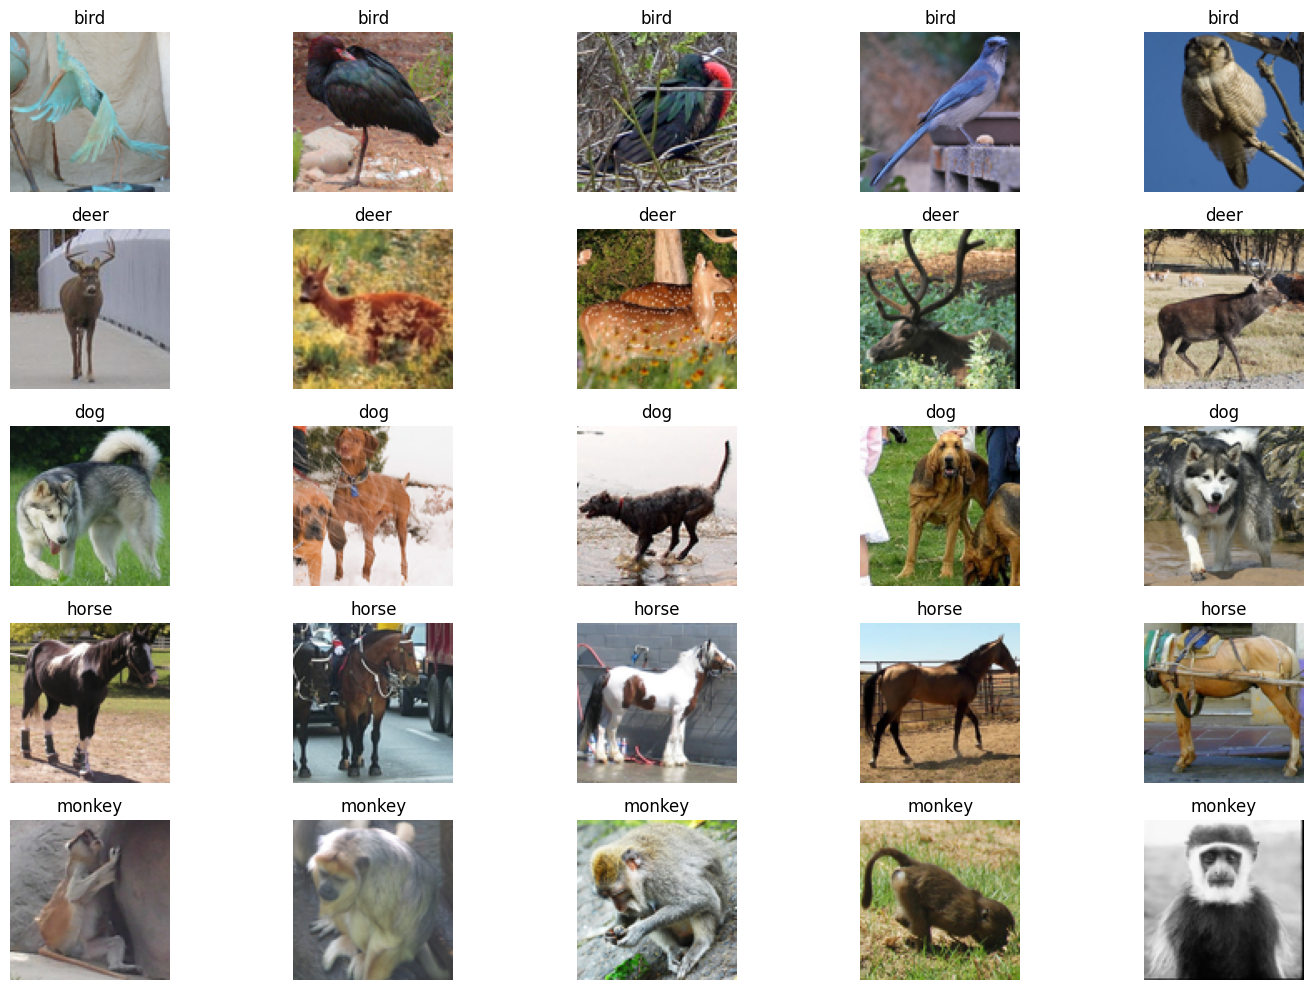

In [32]:
# Define the class mapping for bird, deer, dog, horse, and monkey
class_mapping = {1: 'bird', 4: 'deer', 5: 'dog', 6: 'horse', 7: 'monkey'}

# Visualize STL-10 classes
visualise_stl10(class_mapping)

After visualizing the data, implement the `STL10_loader` class to create a custom data loader that initializes the dataset, extracts the target classes, and applies the necessary image transformations. Once these tasks are completed, you will move on to fine-tuning the ConvNet on this dataset in the next section.

In [35]:
class STL10_loader(Dataset):
    def __init__(self, root, train=True, transform=None):
        '''
        Initializes the STL10 dataset.

        Args:
            root (str): Root directory of the dataset.
            train (bool): If True, use the training set, otherwise use the test set.
            transform (callable, optional): A function/transform to apply to the images.
        '''

        # Load the STL-10 dataset
        self.dataset = datasets.STL10(root=root, split='train' if train else 'test', download=True, transform=transform)
        self.transform = transform
        
        # Define the classes you want to keep
        self.class_indices = [1, 4, 5, 6, 7]  # Bird, deer, dog, horse, monkey
        
        # Filter dataset to only include the desired classes
        self.filtered_data = []
        self.filtered_labels = []

        for img, label in self.dataset:
            if label in self.class_indices:
                self.filtered_data.append(img)
                # Adjust label to match the new class indices (0-4)
                self.filtered_labels.append(self.class_indices.index(label))
        
    def __len__(self):
        '''
        Returns the number of samples in the dataset.
        '''

        return len(self.filtered_labels)

    def __getitem__(self, idx):
        '''
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the transformed image and its target label.
        '''

        img = self.filtered_data[idx]  # Get the filtered image
        label = self.filtered_labels[idx]  # Get the filtered label

        return img, label

<a id="section-9"></a>
### **Section 9: Fine-tuning ConvNet on STL-10 (14 points)**

In this section, you will load the pre-trained parameters of the ConvNet (trained on CIFAR-100) and modify the output layer to adapt it to the new dataset containing 5 classes. You can either first load the pre-trained parameters and then modify the output layer, or change the output layer before loading the matched pre-trained parameters. Once modified, you will train the model and document the settings of hyperparameters, accuracy, and learning curve. Additionally, visualize both the training loss and accuracy to assess the learning process. To gain a deeper understanding of the feature learning process, consider using techniques like [**t-sne**](https://lvdmaaten.github.io/tsne/) for feature space visualization.

In [36]:
# Create data loaders for the entire STL-10 dataset
stl10_train_loader = DataLoader(STL10_loader(root='./data', train=True, transform=transformations_list[0]),
                                batch_size=1024,
                                shuffle=True,
                                num_workers=os.cpu_count(),
                                drop_last=True,
                                multiprocessing_context="fork",
                                pin_memory=True)

stl10_test_loader = DataLoader(STL10_loader(root='./data', train=False, transform=transformations_list[0]),
                                batch_size=1024,
                                shuffle=False,
                                num_workers=os.cpu_count(),
                                drop_last=True,
                                multiprocessing_context="fork",
                                pin_memory=True)

Files already downloaded and verified
Files already downloaded and verified


In [37]:
# Agnostic Code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Date
now = datetime.now()
current_date = now.strftime("%Y_%m_%d_%H_%M_%S")

# Define the model
fineTunedModel = ConvNet(num_classes=5).to(device)

# Pre-Trained model
pretrained_path = "models/HyperparameterTuningForLonger/ConvNet/convnet_cifar100_2024_10_14_12_43_23.pth"
pretrained_dict = torch.load(pretrained_path)

print("Pretrained model state_dict keys:", pretrained_dict.keys())
# Remove the last layer from the pretrained model
pretrained_dict.pop("classifier.3.weight")
pretrained_dict.pop("classifier.3.bias")

# Load the pretrained model state_dict
fineTunedModel.load_state_dict(pretrained_dict, strict=False)

fineTunedModel.classifier = nn.Sequential(
            nn.Flatten(),                                                   # Flatten the output
            nn.Linear(120 * 17 * 17, 84),                                             # F6: Fully connected layer
            nn.Tanh(),                                                      # Activation
            nn.Linear(84, 5),                                     # Output layer: 100 classes
        )

# Learning rate
LEARNING_RATE = 0.0035048274683532345

# Create optimizer
optimizer = torch.optim.AdamW(fineTunedModel.parameters(),
                              lr=LEARNING_RATE,
                              eps=1e-8,
                              amsgrad=True,
                              weight_decay=4.296574620460814e-05)

# Loss function
loss_fn = nn.CrossEntropyLoss()

# Optional learning rate scheduler (if needed)
scheduler = None  # Define scheduler if needed

# Writer
writer = create_writer(experiment_name="stl10",
                        model_name="ConvNetSTL10FinedTuned",
                        timestamp=current_date)

# Start timer to track training time
train_time_start = timer()

# Train the model
train(model=fineTunedModel,
      train_dataloader=stl10_train_loader,
      val_dataloader=stl10_test_loader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=100,
      device=device,
      writer=writer,  # Pass TensorBoard
        learning_rate_scheduler=scheduler)

# End timer
train_time_end = timer()

# Print total training time
print(f"Training took {train_time_end - train_time_start:.2f} seconds.")

# Save the model
save_model(model=fineTunedModel,
           target_dir="models/ConvNetSTL10FinedTuned",
           model_name="finetuned_convnet_stl10.pth")

writer.close()

Pretrained model state_dict keys: odict_keys(['conv_blocks.0.weight', 'conv_blocks.0.bias', 'conv_blocks.3.weight', 'conv_blocks.3.bias', 'conv_blocks.6.weight', 'conv_blocks.6.bias', 'classifier.1.weight', 'classifier.1.bias', 'classifier.3.weight', 'classifier.3.bias'])
[INFO] Created SummaryWriter, saving to: runs/stl10/ConvNetSTL10FinedTuned/2024_10_18_06_10_19...


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Epoch 1:   0%|          | 0/2 [00:00<?, ?it/s]

Testing Epoch 1:   0%|          | 0/3 [00:00<?, ?it/s]

Training Epoch 2:   0%|          | 0/2 [00:00<?, ?it/s]

...

Training Epoch 99:   0%|          | 0/2 [00:00<?, ?it/s]

Testing Epoch 99:   0%|          | 0/3 [00:00<?, ?it/s]

Training Epoch 100:   0%|          | 0/2 [00:00<?, ?it/s]

Testing Epoch 100:   0%|          | 0/3 [00:00<?, ?it/s]

Training took 535.87 seconds.
[INFO] Saving model to: models/ConvNetSTL10FinedTuned/finetuned_convnet_stl10.pth


<a id="section-10"></a>
### **Section 10: Bonus Challenge (optional)**

Try to achieve the highest possible accuracy on the test dataset (5 classes from STL-10) by adjusting hyperparameters, modifying architectures, or applying techniques like data augmentation. The top-performing teams will earn bonus points that can significantly boost their final lab grade, even allowing it to exceed 10 (up to 11):

- **1st place:** +1.0 to the final grade of the final lab
- **2nd place:** +0.8 to the final grade of the final lab
- **3rd place:** +0.6 to the final grade of the final lab
- **4th place:** +0.4 to the final grade of the final lab
- **5th place:** +0.2 to the final grade of the final lab

**Hint:** You may use techniques like data augmentation, freezing early layers, modifying architecture, or optimizing hyperparameters. Only data from CIFAR-100 and STL-10 can be used, and you cannot add more than 3 additional convolutional layers.

In [42]:
class ConvNetSTL(nn.Module):

    def __init__(self, num_classes=5):
        '''	
        Initializes the convolutional neural network model.

        Args:
            None
        '''

        super(ConvNetSTL, self).__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

        

    def forward(self, x):
        '''
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor.
        '''
        return self.layers(x)


In [51]:
# Define data augmentation transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Randomly flip images horizontally
    transforms.RandomResizedCrop(96),  # Randomly crop and resize the image
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Randomly change brightness, contrast, saturation, and hue
    transforms.ToTensor(),  # Convert the image to a tensor
    transforms.Normalize((0.4408, 0.4279, 0.3867), (0.2682, 0.2610, 0.2686))  # Normalize the image
])

transform_test = transforms.Compose([
    transforms.Resize(96),  # Resize the image
    transforms.ToTensor(),  # Convert the image to a tensor
    transforms.Normalize((0.4408, 0.4279, 0.3867), (0.2682, 0.2610, 0.2686))  # Normalize the image
])

In [52]:
# Create data loaders for the entire STL-10 dataset
stl10_train_loader = DataLoader(STL10_loader(root='./data', train=True, transform=transform_train),
                                batch_size=64,
                                shuffle=True,
                                num_workers=os.cpu_count(),
                                drop_last=True,
                                multiprocessing_context="fork",
                                pin_memory=True)

stl10_test_loader = DataLoader(STL10_loader(root='./data', train=False, transform=transform_test),
                                batch_size=64,
                                shuffle=False,
                                num_workers=os.cpu_count(),
                                drop_last=True,
                                multiprocessing_context="fork",
                                pin_memory=True)

Files already downloaded and verified
Files already downloaded and verified


In [53]:
# Batch size
BATCH_SIZE = 64

# Number of workers
NUM_OF_WORKERS = os.cpu_count()

# Get current date and time for naming the model
now = datetime.now()
current_date = now.strftime("%Y_%m_%d_%H_%M_%S")

# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model and move it to the appropriate device
ConvNetSTLModel = ConvNetSTL().to(device)


# Learning rate
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

# Number of epochs
EPOCHS = 100

# Create optimizer
optimizer = torch.optim.Adam(ConvNetSTLModel.parameters(),
                                  lr=LEARNING_RATE,
                                  eps=1e-8,
                                  amsgrad=True,
                                  weight_decay=WEIGHT_DECAY)

# Loss function
loss_fn = nn.CrossEntropyLoss()

print(f"Training on device {device}.")

# # Initialize the weights of the model
xavier_uniform_init(ConvNetSTLModel)

# Optional learning rate scheduler (if needed)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 60, 80], gamma=0.5)

# Writer
writer = create_writer(experiment_name="stl10",
                        model_name="ConvNetSTL10Challenge",
                        timestamp=current_date)

# Add Hyperparameters to TensorBoard
writer.add_hparams({"batch_size": BATCH_SIZE,
                    "num_epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "num_of_workers": NUM_OF_WORKERS,
                    "loss_function": loss_fn.__class__.__name__,
                    "optimizer": optimizer.__class__.__name__,
                    "device": str(device),
                    "model_parameters": sum(p.numel() for p in ConvNetSTLModel.parameters() if p.requires_grad),

}, 
{})
# writer.add_graph(model=ConvNetSTLModel, 
#                   input_to_model=torch.randn(1, 3, 96, 96).to(device),
#                     verbose=False)

print("Training the model...")

# Assuming the `train` function is defined elsewhere
train(model=ConvNetSTLModel,
      train_dataloader=stl10_train_loader,
      val_dataloader=stl10_test_loader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=EPOCHS,
      device=device,
      writer=writer,  # Pass TensorBoard writer or None if not using it
      learning_rate_scheduler=scheduler)

# Save the model
save_model(model=ConvNetSTLModel,
           target_dir="models/ConvNetSTL10Challenge",
           model_name=f"convnet_stl10_challenge{current_date}.pth")

writer.close()

Training on device cuda.
[INFO] Created SummaryWriter, saving to: runs/stl10/ConvNetSTL10Challenge/2024_10_18_10_42_50...
Training the model...


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training Epoch 1:   0%|          | 0/39 [00:00<?, ?it/s]

Testing Epoch 1:   0%|          | 0/62 [00:00<?, ?it/s]

Training Epoch 2:   0%|          | 0/39 [00:00<?, ?it/s]

...

Training Epoch 99:   0%|          | 0/39 [00:00<?, ?it/s]

Testing Epoch 99:   0%|          | 0/62 [00:00<?, ?it/s]

Training Epoch 100:   0%|          | 0/39 [00:00<?, ?it/s]

Testing Epoch 100:   0%|          | 0/62 [00:00<?, ?it/s]

[INFO] Saving model to: models/ConvNetSTL10Challenge/convnet_stl10_challenge2024_10_18_10_42_50.pth


<a id="section-x"></a>
### **Section X: Individual Contribution Report *(Mandatory)***

Because we want each student to contribute fairly to the submitted work, we ask you to fill out the textcells below. Write down your contribution to each of the assignment components in percentages. Naturally, percentages for one particular component should add up to 100% (e.g. 30% - 30% - 40%). No further explanation has to be given.

| Name | Contribution on Research | Contribution on Programming | Contribution on Writing |
| -------- | ------- | ------- | ------- |
| Piotr | 33 % | 33 % | 34 % |
| Thomas  | 34 % | 33 % | 33 % |
| Pedro | 33 % | 34 % | 33 % |

### - End of Notebook -